# AIG WL Expressiveness Analysis

**Question.** For each AIG benchmark, is a 1-WL graph representation enough to
predict the *value proxy*

$$y(g) = \min_{r \in \mathcal{R}} \text{numAnd}\bigl(r(g)\bigr)$$

where $\mathcal{R}$ is the set of 7 ABC heuristic recipes
(`resyn`, `resyn2a`, `resyn2rs`, `resyn3`, `compress`, `compress2`, `compress2rs`)
applied to an AIG obtained after a random 5-step prefix of basic actions?

If yes, an MPNN-based critic on top of vanilla 1-WL coloring can in principle
learn $y$ — so message passing is sufficient and no fancier architecture is needed.

**Plan.**
1. Setup & data loading.
2. Target distribution per benchmark — *rule out the trivial explanation*.
3. Engineered-feature baseline (random forest on the 10 scalars from `res.npz`).
4. Representation ladder via cross-validated nMSE.
5. graphtester information-theoretic floor on 1-WL coloring (R1 anonymous vs R2 input-identified).
6. Paired statistical tests (effect sizes, not just p-values).
7. Permutation null control.
8. Summary & interpretation.


## 1. Setup & imports


In [1]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error

from scipy.stats import wilcoxon

import igraph as ig

warnings.filterwarnings("ignore")
np.random.seed(0)

# graphtester + abc_py (optional; protected so notebook still runs partially)
try:
    import graphtester as gt
    from graphtester.io.dataset import Dataset
    HAVE_GT = True
except Exception as e:
    print("graphtester not available:", e)
    HAVE_GT = False

try:
    from abc_py import AbcInterface
    HAVE_ABC = True
except Exception as e:
    print("abc_py not available:", e)
    HAVE_ABC = False

print("graphtester:", HAVE_GT, " | abc_py:", HAVE_ABC)


graphtester: True  | abc_py: True


## 2. Data loading helpers

- `X` (N, 10): the 10 engineered scalar features of `test_sklearn.py`.
- `Y_all` (N, 7): `numAnd` after each of the 7 ABC recipes.
- `y_min` (N,): `y = min over recipes` — the value proxy we want to predict.
- `aig_path(aig, i)`: the i-th AIG file produced by the 5-step prefix.

Constants `AIGS`, `HEURISTICS`, `FEATURE_NAMES` are reused everywhere below.


In [2]:
AIGS = [f'ex{i}' for i in range(200, 300)]

HEURISTICS = [
    "resyn", "resyn2a", "resyn2rs", "resyn3",
    "compress", "compress2", "compress2rs",
]

FEATURE_NAMES = [
    "balance", "rewrite", "rewrite-zero", "refactor", "refactor-zero",
    "normalized_ands", "normalized_levels",
    "normalized_prev_ands", "normalized_prev_levels", "time",
]

DATASET_ROOT = Path("../../sb3-abc")
N_PER_AIG = 1000  # 3125 samples per benchmark
OUT_DIR = Path("analysis_out_2026")
OUT_DIR.mkdir(exist_ok=True)


def load(aig: str):
    """Load a dataset. Returns (X, Y_all, y_min) or raises FileNotFoundError."""
    p = DATASET_ROOT / f"dataset-{aig}" / "res.npz"
    data = np.load(p)
    X = data["x"]
    Y_all = data["y"]
    y_min = np.amin(Y_all, axis=1)
    return X, Y_all, y_min


def aig_path(aig: str, i: int) -> Path:
    return DATASET_ROOT / f"dataset-{aig}" / f"{i}.aig"


# Discover which datasets are actually available on disk.
available = []
missing = []
for a in AIGS:
    try:
        load(a)
        available.append(a)
    except FileNotFoundError:
        print(f"[skip] {a}: dataset missing")
        missing.append(a)
print("Available datasets:", len(available))


[skip] ex206: dataset missing
[skip] ex207: dataset missing
[skip] ex220: dataset missing
[skip] ex222: dataset missing
[skip] ex223: dataset missing
[skip] ex224: dataset missing
[skip] ex225: dataset missing
[skip] ex226: dataset missing
[skip] ex227: dataset missing
[skip] ex252: dataset missing
[skip] ex259: dataset missing
[skip] ex264: dataset missing
[skip] ex273: dataset missing
[skip] ex274: dataset missing
[skip] ex294: dataset missing
[skip] ex297: dataset missing
[skip] ex298: dataset missing
[skip] ex299: dataset missing
Available datasets: 82


In [ ]:
np.save('missing', missing)

## 3. Target distribution per benchmark — ruling out the trivial explanation

Before any modelling, we ask: **how much variance is there to explain?**
The metric we will use everywhere below is

$$\text{nMSE} = \frac{\text{MSE}}{\mathrm{Var}(y)} \;=\; 1 - R^2.$$

The trivial constant predictor $\hat y = \bar y$ has $\text{nMSE} = 1$ by construction.
If $\mathrm{Var}(y)$ is tiny relative to typical $y$ values (small coefficient of variation
$\mathrm{CV} = \sigma/|\mu|$), the prediction task itself is **trivial**, and any claim of
the form "WL iter-0 is enough to predict $y$" carries no information.


In [ ]:
rows = []
distributions = {}

for aig in available:
    _, Y_all, y_min = load(aig)
    distributions[aig] = (Y_all, y_min)
    mean = float(np.mean(y_min))
    std = float(np.std(y_min))
    var = float(np.var(y_min))
    vmin, vmax = float(y_min.min()), float(y_min.max())
    rng = vmax - vmin
    cv = std / abs(mean) if mean else float("nan")
    rows.append(dict(aig=aig, N=len(y_min), mean=mean, std=std,
                     var=var, range=rng, CV=cv))

dist_df = pd.DataFrame(rows).set_index("aig")
dist_df.round(4)


In [ ]:
# Per-AIG violin: 7 heuristics + y_min, highlighted.
for aig, (Y_all, y_min) in distributions.items():
    labels = HEURISTICS + ["min (=y)"]
    data = [Y_all[:, i] for i in range(Y_all.shape[1])] + [y_min]

    fig, ax = plt.subplots(figsize=(9, 4.2))
    parts = ax.violinplot(data, showmeans=True, showextrema=True)
    for i, body in enumerate(parts["bodies"]):
        body.set_facecolor("tab:orange" if i == len(data) - 1 else "steelblue")
        body.set_alpha(0.6)
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("numAnd")
    ax.set_title(
        f"{aig}: N={len(y_min)}, Var(y)={np.var(y_min):.2f}, "
        f"range={y_min.max() - y_min.min():.0f}, CV={dist_df.loc[aig, 'CV']:.4f}"
    )
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"analysis_dist_{aig}.png", dpi=130)
    plt.show()


In [ ]:
# Overview: Var, range, CV across all benchmarks.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
xs = dist_df.index.tolist()
axes[0].bar(xs, dist_df["var"], color="steelblue"); axes[0].set_title("Var(y)")
axes[1].bar(xs, dist_df["range"], color="darkorange"); axes[1].set_title("range(y)")
axes[2].bar(xs, dist_df["CV"], color="seagreen"); axes[2].set_title("CV = std/|mean|")
for ax in axes:
    ax.tick_params(axis="x", rotation=40)
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(OUT_DIR / "analysis_overview_ex.png", dpi=130)
plt.show()


## 4. Engineered-feature baseline (random forest on 10 scalars)

`X` contains 10 hand-crafted scalars (action counters and normalized
size/level statistics) used downstream as the state of the RL agent. If a
random forest on those 10 numbers already achieves nMSE close to 0, then a
GNN on the AIG can at best match this — and the WL-expressiveness question
becomes interesting only insofar as iter-0 WL ≈ these 10 scalars.

For each benchmark we report:
- 5-fold cross-validated nMSE (out-of-fold predictions);
- in-sample feature importances + their std across trees;
- a depth-8 decision tree on the top-2 features, as a visual sanity check
  of the structure.


In [3]:
def nmse(y_true, y_pred):
    return float(mean_squared_error(y_true, y_pred) / np.var(y_true))


def cv_nmse(model_factory, X, y, n_splits=5):
    """Return out-of-fold predictions and overall nMSE."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    y_hat = cross_val_predict(model_factory(), X, y, cv=kf, n_jobs=-1)
    return y_hat, nmse(y, y_hat)

In [4]:
PI_TYPES = {2}
PO_TYPES = {1}
CONST_TYPES = {0}


def extract_aig(abc):
    n = abc.numNodes()
    node_types = np.zeros(n, dtype=int)
    edges = []
    for i in range(n):
        node = abc.aigNode(i)
        node_types[i] = node.nodeType()
        if node.hasFanin0():
            edges.append((node.fanin0(), i))
        if node.hasFanin1():
            edges.append((node.fanin1(), i))
    edges = np.asarray(edges, dtype=int) if edges else np.zeros((0, 2), dtype=int)
    return node_types, edges


## 6. graphtester information-theoretic floor

`graphtester.evaluate(..., metrics=["lower_bound_mse"])` computes, for a chosen
$k$-WL representation, the **minimum MSE achievable by any function of the
coloring** on the training set:

$$\mathrm{LB}_k(\mathcal D) = \min_{f}\, \mathbb E_{(g, y) \in \mathcal D}\,
\bigl(y - f(\text{WL}_k(g))\bigr)^2 \;.$$

This is a lower bound on what any MPNN with matching power can achieve.
Two AIG representations:

- **R1 (anonymous):** node labels are the abc_py type codes (PI / PO / AND / NOT-AND / …). This is what a vanilla GCN/MPNN sees.
- **R2 (input-identified):** each PI gets a unique label (`PI_0`, `PI_1`, …). Models the effect of PI positional encoding.

**Caveat.** $\mathrm{LB}_k$ is computed on the training set. If WL produces a
*unique signature per graph*, the optimum is the lookup table
`signature → y` and $\mathrm{LB}_k = 0$ trivially. We therefore also report
the **uniqueness ratio** = (# distinct signatures) / N per iteration as a
sanity check.


In [5]:
from joblib import Parallel, delayed

def _build_digraph(node_labels, edges):
    n = len(node_labels)
    edge_list = [(int(s), int(d)) for s, d in edges] if len(edges) else []
    g = ig.Graph(n=n, edges=edge_list, directed=False)
    g.vs["label"] = [str(lab) for lab in node_labels]
    return g


def build_R1(node_types, edges):
    return _build_digraph(node_types, edges)


# def build_R2(node_types, edges):
#     labels = []
#     pi_idx = 0
#     for t in node_types:
#         if t in PI_TYPES:
#             labels.append(f"PI_{pi_idx}")
#             pi_idx += 1
#         else:
#             labels.append(int(t))
#     return _build_digraph(labels, edges)


def _extract_one(path: str):
    """Load one AIG file in a subprocess and return (node_types, edges)."""
    from abc_py import AbcInterface
    man = AbcInterface(); man.end(); man.start()
    man.read(path)
    n = man.numNodes()
    node_types = np.zeros(n, dtype=int)
    edges = []
    for i in range(n):
        node = man.aigNode(i)
        node_types[i] = node.nodeType()
        if node.hasFanin0():
            edges.append((node.fanin0(), i))
        if node.hasFanin1():
            edges.append((node.fanin1(), i))
    edges = np.asarray(edges, dtype=int) if edges else np.zeros((0, 2), dtype=int)
    man.end()
    return node_types, edges


def load_raw_aigs(aig: str):
    """Return list of (node_types, edges) per graph, cached on disk."""
    cache = OUT_DIR / f"raw_{aig}.npz"
    if cache.exists():
        print('cached')
        d = np.load(cache, allow_pickle=True)
        return list(zip(d["types"], d["edges"]))
    if not HAVE_ABC:
        raise RuntimeError("abc_py unavailable")
    paths = [str(aig_path(aig, i)) for i in range(N_PER_AIG)]
    results = Parallel(n_jobs=12, backend="loky")(
        delayed(_extract_one)(p) for p in paths
    )
    types_list, edges_list = zip(*results)
    np.savez(cache,
             types=np.array(list(types_list), dtype=object),
             edges=np.array(list(edges_list), dtype=object))
    return list(zip(types_list, edges_list))


In [6]:
import pickle

WL_ITERS = 2
WL_CURVES_CACHE = OUT_DIR / "wl_curves.pkl"
wl_curves = {}  # aig -> dict(R1=..., R2=...)

if WL_CURVES_CACHE.exists():
    with open(WL_CURVES_CACHE, "rb") as f:
        wl_curves = pickle.load(f)
    print(f"Loaded wl_curves from cache ({len(wl_curves)} AIGs).")
elif HAVE_GT and HAVE_ABC:
    for aig in available:
        print(aig)
        _, _, y = load(aig)
        raw = load_raw_aigs(aig)
        y_var = float(np.var(y))
        curves = {}
        for name, builder in [("R1_anonymous", build_R1)]:
            graphs = [builder(t, e) for (t, e) in raw]
            ds = Dataset(graphs=graphs, labels=y.tolist(), name=name)
            ev = gt.evaluate(
                ds,
                ignore_node_features=False,
                ignore_edge_features=True,
                metrics=["lower_bound_mse"],
                iterations=WL_ITERS,
            )
            df = ev.as_dataframe()
            curves[name] = {
                "lb": df["Lower Bound MSE"].to_numpy(),
                "n_iter": np.arange(len(df)),
            }
        wl_curves[aig] = dict(curves=curves, y_var=y_var)
    with open(WL_CURVES_CACHE, "wb") as f:
        pickle.dump(wl_curves, f)
    print(f"Saved wl_curves to {WL_CURVES_CACHE}.")
else:
    print("Skipping WL bound (graphtester or abc_py missing).")


ex200
cached
ex201
cached
ex202
cached
ex203
cached
ex204
cached
ex205
cached
ex208
cached
ex209
cached
ex210
cached
ex211
cached
ex212
cached
ex213
cached
ex214
cached
ex215
cached
ex216
cached
ex217
cached
ex218
cached
ex219
cached
ex221
cached
ex228
cached
ex229
cached
ex230
cached
ex231
cached
ex232
cached
ex233
cached
ex234
cached
ex235
cached
ex236
cached
ex237
cached
ex238
cached
ex239
cached
ex240
cached
ex241
cached
ex242
cached
ex243
cached
ex244
cached
ex245
cached
ex246
cached
ex247
cached
ex248
cached
ex249
cached
ex250
cached
ex251
cached
ex253
cached
ex254
cached
ex255
cached
ex256
cached
ex257
cached
ex258
cached
ex260
cached
ex261
cached
ex262
cached
ex263
cached
ex265
cached
ex266
cached
ex267
cached
ex268
cached
ex269
cached
ex270
cached
ex271
cached
ex272
cached
ex275
cached
ex276
cached
ex277
cached
ex278
cached
ex279
cached
ex280
cached
ex281
cached
ex282
cached
ex283
cached
ex284
cached
ex285
cached
ex286
cached
ex287
cached
ex288
cached
ex289
cached
ex290
cached

ex200
cached
a
a
a
ex200: done
ex201
cached
a
a
a
ex201: done
ex202
cached
a
a
a
ex202: done
ex203
cached
a
a
a
ex203: done
ex204
cached
a
a
a
ex204: done
ex205
cached
a
a
a
ex205: done
ex208
cached
a
a
a
ex208: done
ex209
cached
a
a
a
ex209: done
ex210
cached
a
a
a
ex210: done
ex211
cached
a
a
a
ex211: done
ex212
cached
a
a
a
ex212: done
ex213
cached
a
a
a
ex213: done
ex214
cached
a
a
a
ex214: done
ex215
cached
a
a
a
ex215: done
ex216
cached
a
a
a
ex216: done
ex217
cached
a
a
a
ex217: done
ex218
cached
a
a
a
ex218: done
ex219
cached
a
a
a
ex219: done
ex221
cached
a
a
a
ex221: done
ex228
cached
a
a
a
ex228: done
ex229
cached
a
a
a
ex229: done
ex230
cached
a
a
a
ex230: done
ex231
cached
a
a
a
ex231: done
ex232
cached
a
a
a
ex232: done
ex233
cached
a
a
a
ex233: done
ex234
cached
a
a
a
ex234: done
ex235
cached
a
a
a
ex235: done
ex236
cached
a
a
a
ex236: done
ex237
cached
a
a
a
ex237: done
ex238
cached
a
a
a
ex238: done
ex239
cached
a
a
a
ex239: done
ex240
cached
a
a
a
ex240: done
ex241
ca

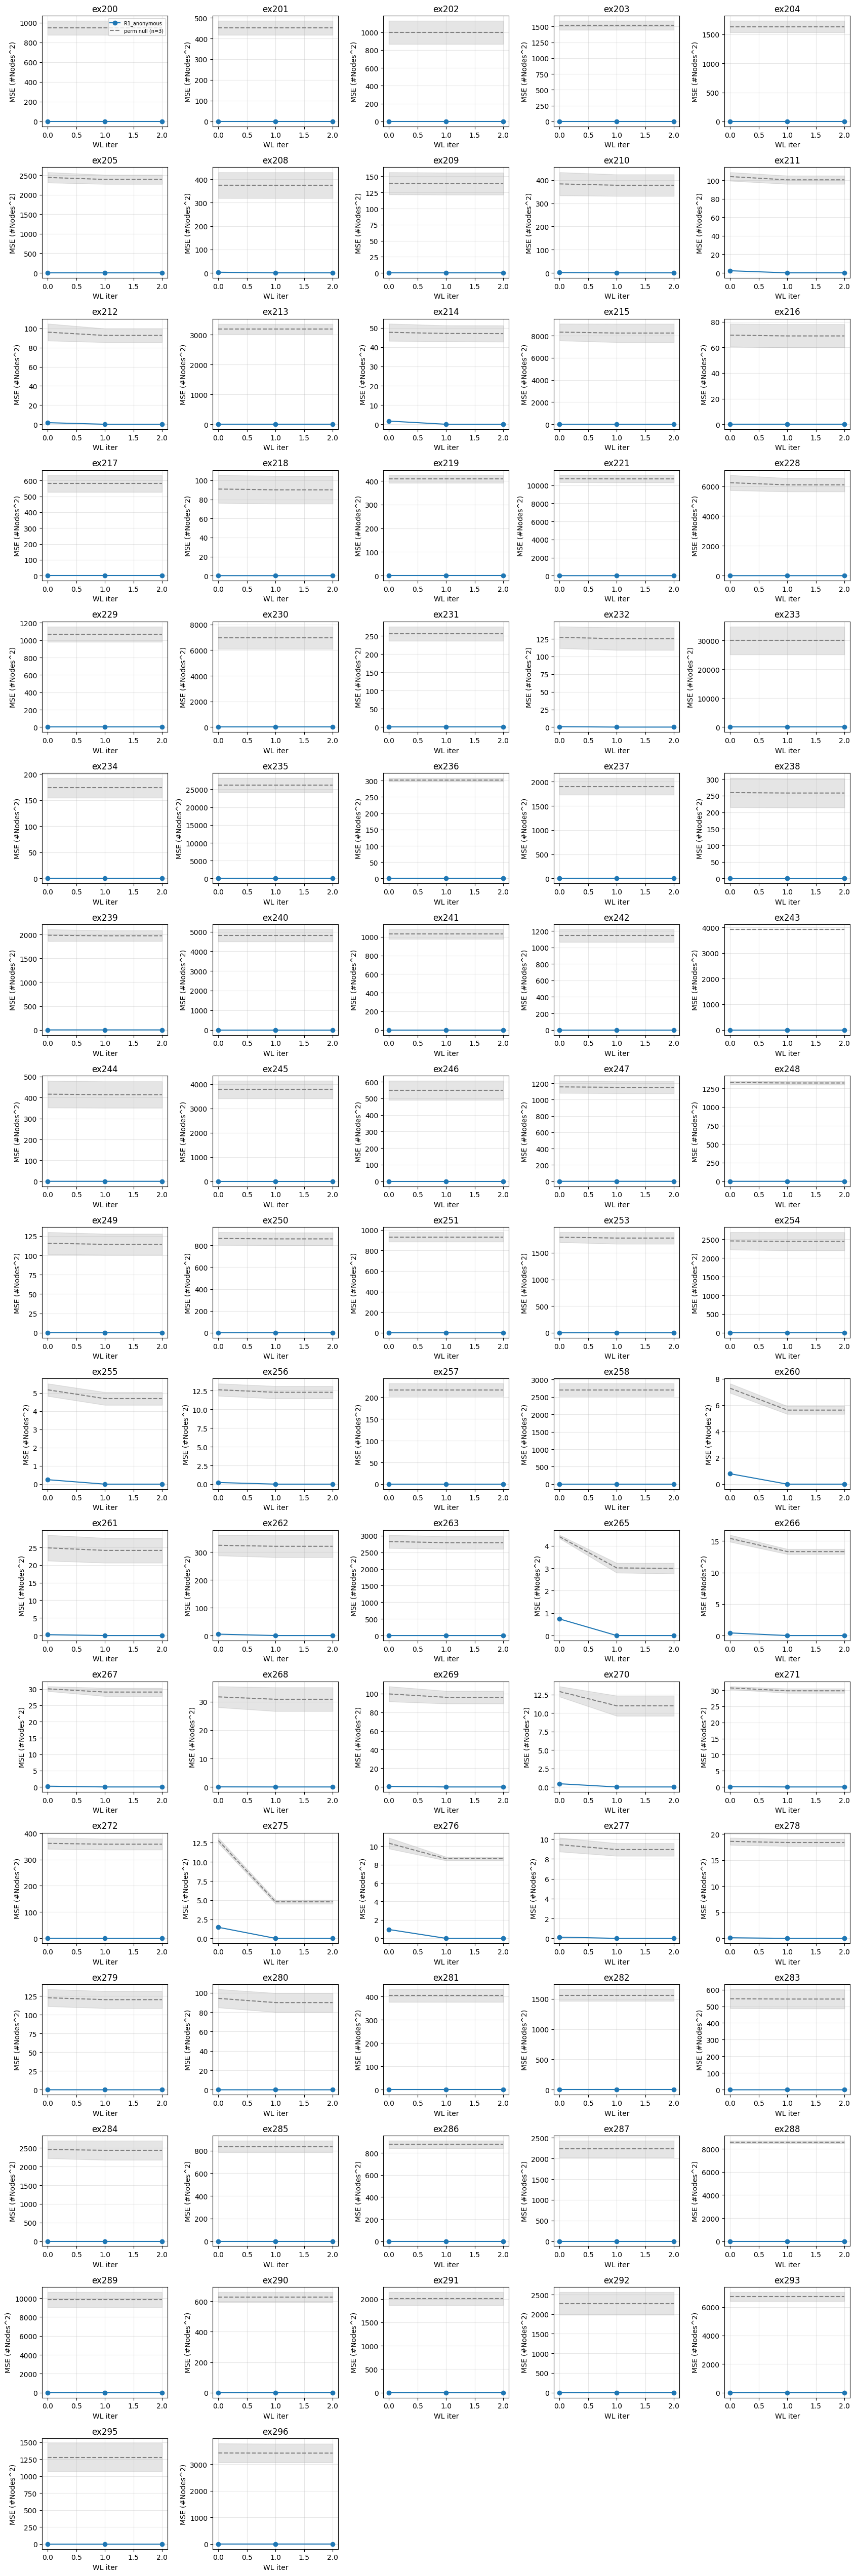

In [10]:
import pickle

N_PERM = 3
WL_PERM_CACHE = OUT_DIR / "wl_perm_nulls.pkl"


def _perm_null_one_aig(aig, y_var, n_perm, wl_iters, seed):
    print(aig)
    """Run n_perm label-permutations for one AIG. Returns (aig, dict(name -> ndarray))."""
    _, _, y = load(aig)
    raw = load_raw_aigs(aig)
    rng_p = np.random.default_rng(seed)
    perm_results = {}
    for name, builder in [("R1_anonymous", build_R1)]:
        graphs = [builder(t, e) for (t, e) in raw]
        perm_lbs = []
        for _ in range(n_perm):
            print('a')
            y_perm = rng_p.permutation(y)
            ds = Dataset(graphs=graphs, labels=y_perm.tolist(), name=name)
            ev = gt.evaluate(
                ds,
                ignore_node_features=False,
                ignore_edge_features=True,
                metrics=["lower_bound_mse"],
                iterations=wl_iters,
            )
            df = ev.as_dataframe()
            perm_lbs.append(df["Lower Bound MSE"].to_numpy())
        perm_results[name] = np.array(perm_lbs)  # (n_perm, wl_iters+1)
    print(f"{aig}: done")
    return aig, perm_results


if WL_PERM_CACHE.exists():
    with open(WL_PERM_CACHE, "rb") as f:
        wl_perm_nulls = pickle.load(f)
    print(f"Loaded wl_perm_nulls from cache ({len(wl_perm_nulls)} AIGs).")
elif wl_curves:
    wl_perm_nulls = {}
    res = []
    for i, aig in enumerate(wl_curves):
        res.append(_perm_null_one_aig(aig, wl_curves[aig]["y_var"], N_PERM, WL_ITERS, seed=i))
    wl_perm_nulls = dict(res)
    with open(WL_PERM_CACHE, "wb") as f:
        pickle.dump(wl_perm_nulls, f)
    print(f"Saved wl_perm_nulls to {WL_PERM_CACHE}.")
else:
    wl_perm_nulls = {}
    print("Skipping permutation null (wl_curves empty).")


if wl_curves:
    n = len(wl_curves)
    ncols = 5
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.0 * nrows),
                             sharey=False, squeeze=False)
    for idx, (aig, payload) in enumerate(wl_curves.items()):
        ax = axes[idx // ncols][idx % ncols]
        yv = payload["y_var"]
        yv=1
        for name, c in payload["curves"].items():
            ax.plot(c["n_iter"], c["lb"] / yv, marker="o", label=name)
            # permutation null band
            if aig in wl_perm_nulls and name in wl_perm_nulls[aig]:
                perm_lbs = wl_perm_nulls[aig][name]          # (N_PERM, iters+1)
                null_mean = perm_lbs.mean(axis=0) / yv
                null_std  = perm_lbs.std(axis=0) / yv
                iters = np.arange(perm_lbs.shape[1])
                ax.plot(iters, null_mean, linestyle="--", color="gray",
                        label=f"perm null (n={N_PERM})")
                ax.fill_between(iters, null_mean - null_std, null_mean + null_std,
                                alpha=0.2, color="gray")

        ax.set_title(f"{aig}")
        ax.set_xlabel("WL iter")
        ax.set_ylabel("MSE (#Nodes^2)")
        ax.grid(alpha=0.3, which="both")
        if idx == 0:
            ax.legend(fontsize=7, loc="upper right")
    # hide unused
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].axis("off")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "analysis_wl_floor.png", dpi=130)
    plt.show()
